In [ ]:
import json
import math

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [ ]:
LOG_FILES = {
    "Kimi Linear": "/content/drive/MyDrive/models/kimi_linear_toy/logs/toy_kimi_linear_half_tinystories_20260501_124445.jsonl",
    "Mamba-2": "/content/drive/MyDrive/models/mamba2_toy/logs/toy_mamba2_half_tinystories_20260501_090228.jsonl",
    "Transformer": "/content/drive/MyDrive/models/transformer_toy2/logs/toy_rope_transformer_half_param_matched_tinystories_20260503_085746.jsonl",
}


OUT_DIR = Path("/content/drive/MyDrive/models/models_figures_focused")
OUT_DIR.mkdir(exist_ok=True)

In [ ]:
BG = "#F9F8F6"

COLORS = {
    "Kimi Linear": "#4878CF",
    "Mamba-2": "#E8873A",
    "Transformer": "#4CAF50",
}

MARKERS = {
    "Kimi Linear": "o",
    "Mamba-2": "s",
    "Transformer": "^",
}

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia", "DejaVu Serif"],
    "axes.facecolor": BG,
    "figure.facecolor": BG,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "legend.framealpha": 0.85,
    "legend.fontsize": 9,
})

In [ ]:
# helpers

def read_jsonl(path):
    path = Path(path)
    records = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            records.append(json.loads(line))
    return records


def first(records, typ):
    for r in records:
        if r.get("type") == typ:
            return r
    return {}


def all_type(records, typ):
    return [r for r in records if r.get("type") == typ]


def pick(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default


def get_model_cfg_value(cfg, key, default=None):
    if key in cfg:
        return cfg[key]
    mc = cfg.get("model_config", {})
    return mc.get(key, default)


def get_status(r):
    if "status" in r:
        return r["status"]
    ts = r.get("training_status")
    if isinstance(ts, dict):
        return ts.get("status")
    return None


def smooth(y, w=5):
    y = np.asarray(y, dtype=float)
    if len(y) < w:
        return y
    kernel = np.ones(w) / w
    return np.convolve(y, kernel, mode="same")


def interp_curve(df, x_col, y_col, grid):
    d = df[[x_col, y_col]].dropna().sort_values(x_col)
    if len(d) < 2:
        return np.full_like(grid, np.nan, dtype=float)
    x = d[x_col].to_numpy()
    y = d[y_col].to_numpy()
    mask = (grid >= x.min()) & (grid <= x.max())
    out = np.full_like(grid, np.nan, dtype=float)
    out[mask] = np.interp(grid[mask], x, y)
    return out

In [ ]:
# Load + normalize

def normalize_run(name, path):
    records = read_jsonl(path)
    cfg = first(records, "run_config")
    final = first(records, "final")
    steps = all_type(records, "step")
    evals = all_type(records, "eval")

    n_params = pick(cfg, "n_params")
    tokens_per_step = pick(
        cfg,
        "tokens_per_optimizer_step",
        "tokens_per_step",
        default=None,
    )

    if tokens_per_step is None:
        final_steps = pick(final, "optimizer_steps", "total_steps")
        final_tokens = pick(final, "tokens_seen", "total_tokens_seen")
        if final_steps and final_tokens:
            tokens_per_step = final_tokens / final_steps

    flops_info = pick(cfg, "estimated_flops", default={})
    flops_per_step = pick(
        cfg,
        "flops_per_step",
        default=flops_info.get("flops_per_step") if isinstance(flops_info, dict) else None,
    )

    final_steps = pick(final, "optimizer_steps", "total_steps")
    final_time_h = pick(final, "total_time_hours")

    step_rows = []
    for r in steps:
        step = pick(r, "optimizer_step", "step")
        tokens_seen = pick(r, "tokens_seen")
        if tokens_seen is None and tokens_per_step is not None:
            tokens_seen = step * tokens_per_step

        elapsed_min = pick(r, "elapsed_min")
        elapsed_h = elapsed_min / 60 if elapsed_min is not None else None
        if elapsed_h is None and final_steps and final_time_h:
            elapsed_h = final_time_h * step / final_steps

        cumulative_flops = pick(r, "cumulative_flops")
        if cumulative_flops is None and flops_per_step is not None:
            cumulative_flops = step * flops_per_step

        step_rows.append({
            "model": name,
            "step": step,
            "train_loss": pick(r, "train_loss", "loss"),
            "train_ppl": pick(r, "train_ppl", "perplexity"),
            "lr": pick(r, "lr"),
            "grad_norm": pick(r, "grad_norm"),
            "tokens_seen": tokens_seen,
            "tokens_b": tokens_seen / 1e9 if tokens_seen is not None else np.nan,
            "tokens_per_sec": pick(r, "tokens_per_sec"),
            "throughput_k": pick(r, "tokens_per_sec", default=np.nan) / 1e3,
            "elapsed_hours": elapsed_h,
            "cumulative_flops": cumulative_flops,
            "pflops": cumulative_flops / 1e15 if cumulative_flops is not None else np.nan,
        })

    eval_rows = []
    for r in evals:
        step = pick(r, "optimizer_step", "step")
        tokens_seen = None
        if tokens_per_step is not None:
            tokens_seen = step * tokens_per_step

        if final_steps and final_time_h:
            elapsed_h = final_time_h * step / final_steps
        else:
            elapsed_h = None

        cumulative_flops = None
        if flops_per_step is not None:
            cumulative_flops = step * flops_per_step

        eval_rows.append({
            "model": name,
            "step": step,
            "split": pick(r, "split", default="val_monitor"),
            "val_loss": pick(r, "val_loss"),
            "val_ppl": pick(r, "val_ppl"),
            "tokens_seen": tokens_seen,
            "tokens_b": tokens_seen / 1e9 if tokens_seen is not None else np.nan,
            "elapsed_hours": elapsed_h,
            "cumulative_flops": cumulative_flops,
            "pflops": cumulative_flops / 1e15 if cumulative_flops is not None else np.nan,
            "best_loss": pick(r, "best_checkpoint_loss", "best_val_loss"),
            "best_step": pick(r, "best_checkpoint_step", "best_step"),
            "status": get_status(r),
        })

    steps_df = pd.DataFrame(step_rows)
    eval_df = pd.DataFrame(eval_rows)

    return {
        "name": name,
        "path": path,
        "records": records,
        "cfg": cfg,
        "final": final,
        "steps": steps_df,
        "evals": eval_df,
        "n_params": n_params,
        "tokens_per_step": tokens_per_step,
        "flops_per_step": flops_per_step,
    }


runs = {name: normalize_run(name, path) for name, path in LOG_FILES.items()}

for name, run in runs.items():
    print(
        f"{name}: "
        f"{len(run['steps'])} step records, "
        f"{len(run['evals'])} eval records, "
        f"params={run['n_params']:,}"
    )

steps_all = pd.concat([r["steps"] for r in runs.values()], ignore_index=True)
evals_all = pd.concat([r["evals"] for r in runs.values()], ignore_index=True)

In [ ]:
summary_rows = []

for name, run in runs.items():
    final = run["final"]
    cfg = run["cfg"]
    eval_df = run["evals"].copy()
    steps_df = run["steps"].copy()

    best_monitor = eval_df["val_loss"].min()
    best_monitor_row = eval_df.loc[eval_df["val_loss"].idxmin()]

    final_step = pick(final, "optimizer_steps", "total_steps")
    tokens_seen = pick(final, "tokens_seen", "total_tokens_seen")
    hours = pick(final, "total_time_hours")
    avg_tps = pick(final, "avg_tokens_per_sec")

    val_ablation = final.get("val_ablation_metrics", {})
    test_rep = final.get("test_replication_metrics", {})

    summary_rows.append({
        "model": name,
        "params_m": run["n_params"] / 1e6,
        "final_step": final_step,
        "tokens_b": tokens_seen / 1e9 if tokens_seen else np.nan,
        "hours": hours,
        "avg_k_tok_s": avg_tps / 1e3 if avg_tps else np.nan,
        "best_monitor_loss": best_monitor,
        "best_monitor_ppl": math.exp(best_monitor),
        "best_monitor_step": int(best_monitor_row["step"]),
        "val_ablation_loss": val_ablation.get("val_loss"),
        "test_replication_loss": test_rep.get("val_loss"),
        "gpu_peak_gb": final.get("gpu_mem_peak_gb"),
        "stopped_early": final.get("stopped_by_early_stopping"),
        "gpu": cfg.get("gpu_name", "RTX PRO 6000"),
    })

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values("best_monitor_loss")
summary.to_csv(OUT_DIR / "summary_metrics.csv", index=False)

print("Summary:")
display(summary)

In [ ]:
# main validation loss vs tokens

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=BG)

for name, run in runs.items():
    d = run["evals"].dropna(subset=["tokens_b", "val_loss"]).sort_values("tokens_b")
    ax.plot(
        d["tokens_b"],
        d["val_loss"],
        color=COLORS[name],
        marker=MARKERS[name],
        markevery=max(1, len(d) // 15),
        linewidth=2.2,
        markersize=4,
        label=name,
    )

ax.set_title("Validation loss vs tokens seen", fontsize=13, pad=10)
ax.set_xlabel("Tokens seen, billions")
ax.set_ylabel("Validation cross-entropy loss")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "01_val_loss_vs_tokens.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
# validation loss vs wall time

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=BG)

for name, run in runs.items():
    d = run["evals"].dropna(subset=["elapsed_hours", "val_loss"]).sort_values("elapsed_hours")
    ax.plot(
        d["elapsed_hours"],
        d["val_loss"],
        color=COLORS[name],
        marker=MARKERS[name],
        markevery=max(1, len(d) // 15),
        linewidth=2.2,
        markersize=4,
        label=name,
    )

ax.set_title("Validation loss vs wall-clock time on RTX PRO 6000", fontsize=13, pad=10)
ax.set_xlabel("Training time, hours")
ax.set_ylabel("Validation cross-entropy loss")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02_val_loss_vs_time.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
# speed-quality Pareto

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)

for _, row in summary.iterrows():
    name = row["model"]
    ax.scatter(
        row["avg_k_tok_s"],
        row["best_monitor_loss"],
        s=130,
        color=COLORS[name],
        marker=MARKERS[name],
        label=name,
        edgecolor="black",
        linewidth=0.7,
    )
    ax.annotate(
        name,
        (row["avg_k_tok_s"], row["best_monitor_loss"]),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_title("Speed-quality trade-off", fontsize=13, pad=10)
ax.set_xlabel("Average throughput, k tokens/sec")
ax.set_ylabel("Best validation loss")
ax.invert_yaxis()
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_speed_quality_pareto.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
#  best validation loss bar chart

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=BG)

bar_order = summary.sort_values("best_monitor_loss")["model"].tolist()
vals = [summary.set_index("model").loc[m, "best_monitor_loss"] for m in bar_order]

bars = ax.bar(
    bar_order,
    vals,
    color=[COLORS[m] for m in bar_order],
    edgecolor="black",
    linewidth=0.7,
)

best = min(vals)
for bar, val in zip(bars, vals):
    delta = val - best
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.4f}\nΔ {delta:+.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Best monitor validation loss", fontsize=13, pad=10)
ax.set_ylabel("Validation loss")
ax.set_ylim(min(vals) - 0.01, max(vals) + 0.04)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_best_val_loss_bar.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
# loss gap relative to Transformer at equal tokens

baseline = "Transformer"
grid = np.linspace(
    evals_all["tokens_b"].dropna().min(),
    evals_all["tokens_b"].dropna().max(),
    300,
)

base_curve = interp_curve(
    runs[baseline]["evals"],
    "tokens_b",
    "val_loss",
    grid,
)

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=BG)

for name, run in runs.items():
    if name == baseline:
        continue

    curve = interp_curve(run["evals"], "tokens_b", "val_loss", grid)
    delta = curve - base_curve

    ax.plot(
        grid,
        delta,
        color=COLORS[name],
        linewidth=2.3,
        label=f"{name} minus {baseline}",
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
ax.set_title("Validation loss gap at equal token budget", fontsize=13, pad=10)
ax.set_xlabel("Tokens seen, billions")
ax.set_ylabel("Loss gap relative to Transformer")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_loss_gap_vs_transformer.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
# throughput over training

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=BG)

for name, run in runs.items():
    d = run["steps"].dropna(subset=["step", "throughput_k"]).sort_values("step")
    y = smooth(d["throughput_k"].to_numpy(), w=11)
    ax.plot(
        d["step"],
        y,
        color=COLORS[name],
        linewidth=2.0,
        label=name,
    )

ax.set_title("Training throughput on RTX PRO 6000", fontsize=13, pad=10)
ax.set_xlabel("Optimizer step")
ax.set_ylabel("Throughput, k tokens/sec")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "06_throughput.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

Kimi Linear: 935 step records, 188 eval records, params=27,285,714
Mamba-2: 890 step records, 179 eval records, params=26,852,384
Transformer: 950 step records, 191 eval records, params=28,739,328

Summary:


/tmp/ipykernel_15825/2411015363.py:252: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  steps_all = pd.concat([r["steps"] for r in runs.values()], ignore_index=True)


,model,params_m,final_step,tokens_b,hours,avg_k_tok_s,best_monitor_loss,best_monitor_ppl,best_monitor_step,val_ablation_loss,test_replication_loss,gpu_peak_gb,stopped_early,gpu
2,Transformer,28.739328,95000,2.334720,1.663,390.000,1.31460,3.723261,95000,1.34535,1.27957,15.367,True,NVIDIA RTX PRO 6000 Blackwell Server Edition
0,Kimi Linear,27.285714,93500,2.297856,4.193,152.246,1.31736,3.733552,93500,1.34756,1.28241,21.700,True,NVIDIA RTX PRO 6000 Blackwell Server Edition
1,Mamba-2,26.852384,89000,2.187264,2.987,203.423,1.35122,3.862134,89000,1.37915,1.31483,23.560,True,NVIDIA RTX PRO 6000 Blackwell Server Edition


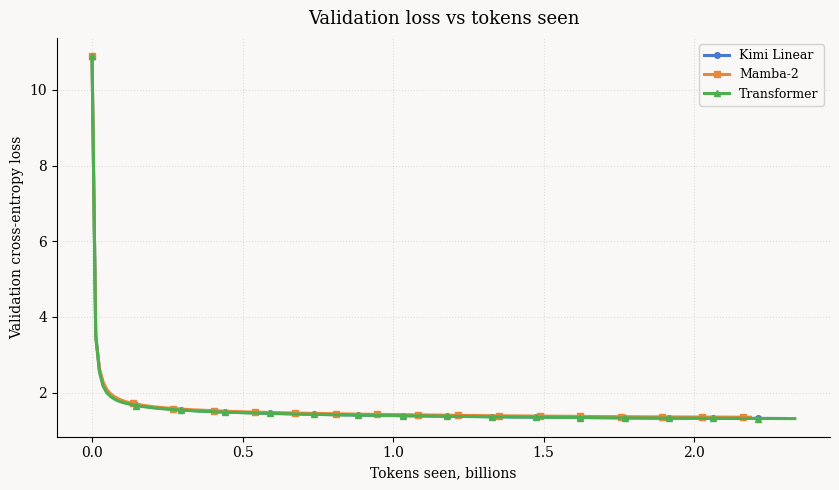

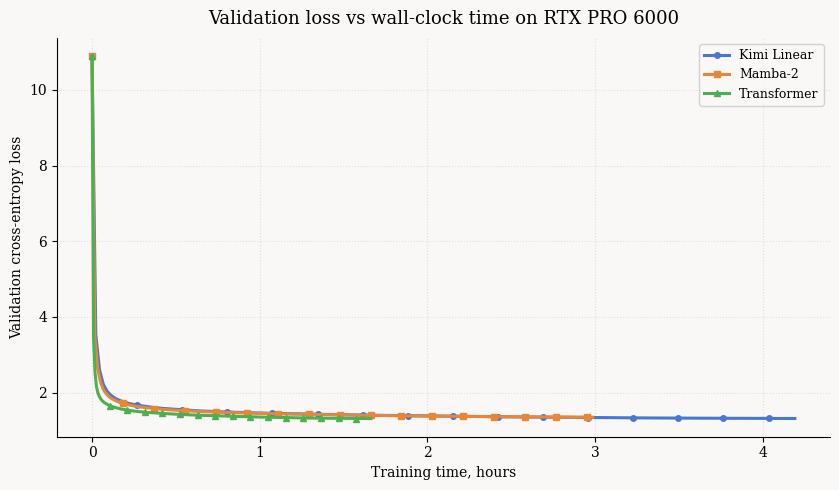

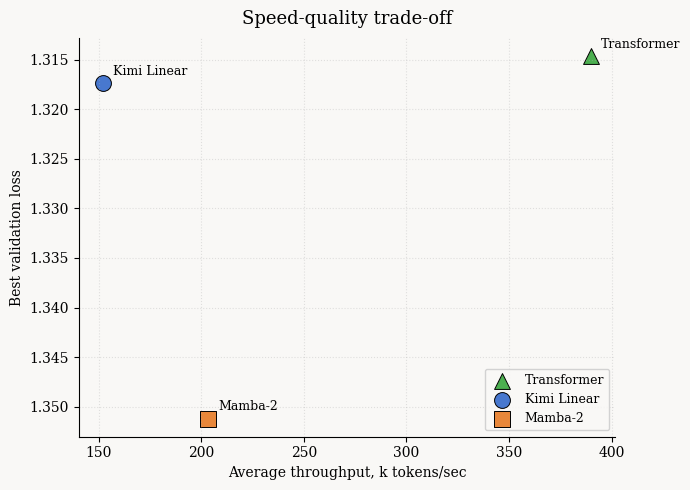

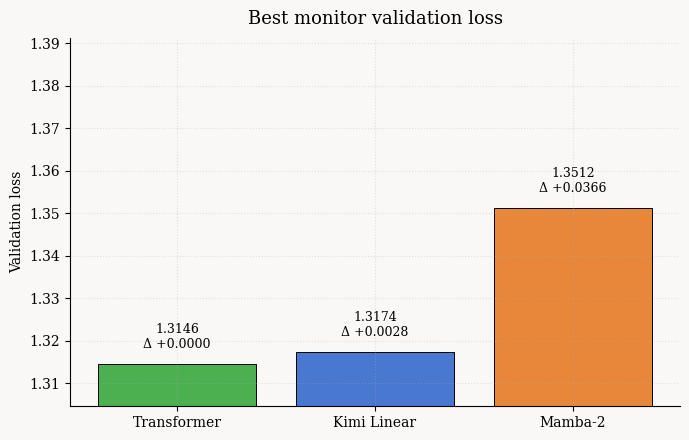

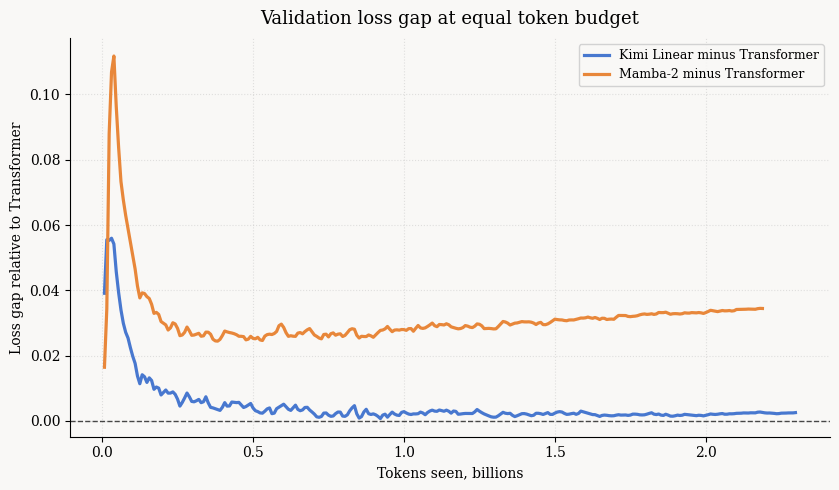

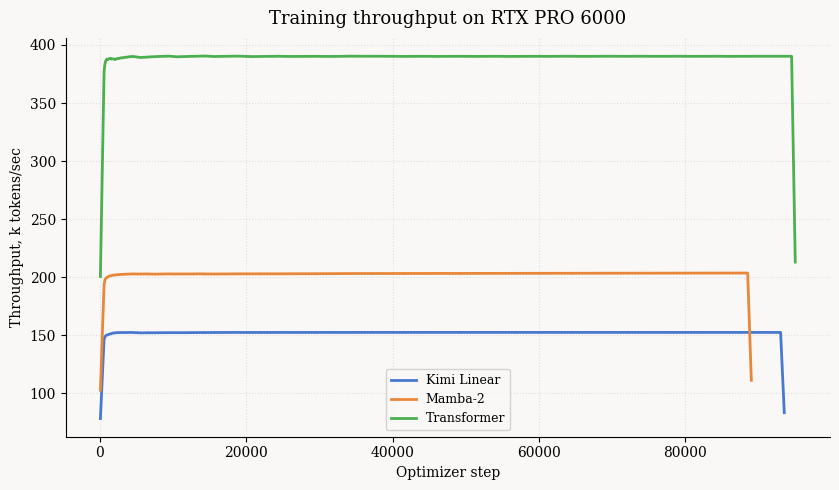


Steps/tokens/time to reach validation-loss thresholds:


model,Kimi Linear,Mamba-2,Transformer
loss_threshold,,,
1.32,88000.0,NaN,84500.0
1.33,75000.0,NaN,73500.0
1.35,62500.0,NaN,61000.0
1.40,38500.0,50000.0,38000.0
1.50,16500.0,20000.0,16000.0
1.60,9000.0,10000.0,8500.0
1.80,4000.0,4500.0,3500.0
2.00,2500.0,2500.0,2000.0



Key takeaways:
- Best monitor validation loss: Transformer
- Highest throughput: Transformer
- Lowest peak GPU memory: Transformer

Saved figures to: /content/drive/MyDrive/models/models_figures_focused


In [ ]:
THRESHOLDS = [2.0, 1.8, 1.6, 1.5, 1.4, 1.35, 1.33, 1.32]

threshold_rows = []

for name, run in runs.items():
    d = run["evals"].dropna(subset=["val_loss"]).sort_values("step")
    for th in THRESHOLDS:
        hit = d[d["val_loss"] <= th]
        if len(hit) == 0:
            threshold_rows.append({
                "model": name,
                "loss_threshold": th,
                "step": np.nan,
                "tokens_b": np.nan,
                "hours": np.nan,
            })
        else:
            r = hit.iloc[0]
            threshold_rows.append({
                "model": name,
                "loss_threshold": th,
                "step": int(r["step"]),
                "tokens_b": r["tokens_b"],
                "hours": r["elapsed_hours"],
            })

thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(OUT_DIR / "thresholds_to_loss.csv", index=False)

print("\nSteps/tokens/time to reach validation-loss thresholds:")
display(thresholds.pivot(index="loss_threshold", columns="model", values="step"))


print("\nSaved figures to:", OUT_DIR.resolve())

In [ ]:
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300
})

def load_validation_logs(log_files_dict, warmup_steps=1000):
    data = []
    for model_name, file_path in log_files_dict.items():
        try:
            with open(file_path, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    # Isolate evaluation records containing validation loss
                    if record.get('type') == 'eval' and 'val_loss' in record:
                        # Handle potential naming differences in log keys
                        step = record.get('optimizer_step', record.get('step'))

                        if step is not None and step >= warmup_steps:
                            data.append({
                                'Model': model_name,
                                'Step': step,
                                'Validation Loss': record['val_loss'],
                                'Validation PPL': record.get('val_ppl')
                            })
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found. Skipping.")

    return pd.DataFrame(data)


def plot_metric(df, metric='Validation Loss', title_suffix='', start_step=1000):
    # filter the dataframe to isolate the desired phase of training

    plot_df = df[df['Step'] >= start_step]

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.lineplot(
        data=plot_df,
        x='Step',
        y=metric,
        hue='Model',
        linewidth=2,
        ax=ax
    )

    ax.set_title(f'{metric} Over Training Steps {title_suffix}', fontweight='bold')
    ax.set_xlabel('Optimizer Steps')
    ax.set_ylabel(metric)

    plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Generating full post-warmup plots...


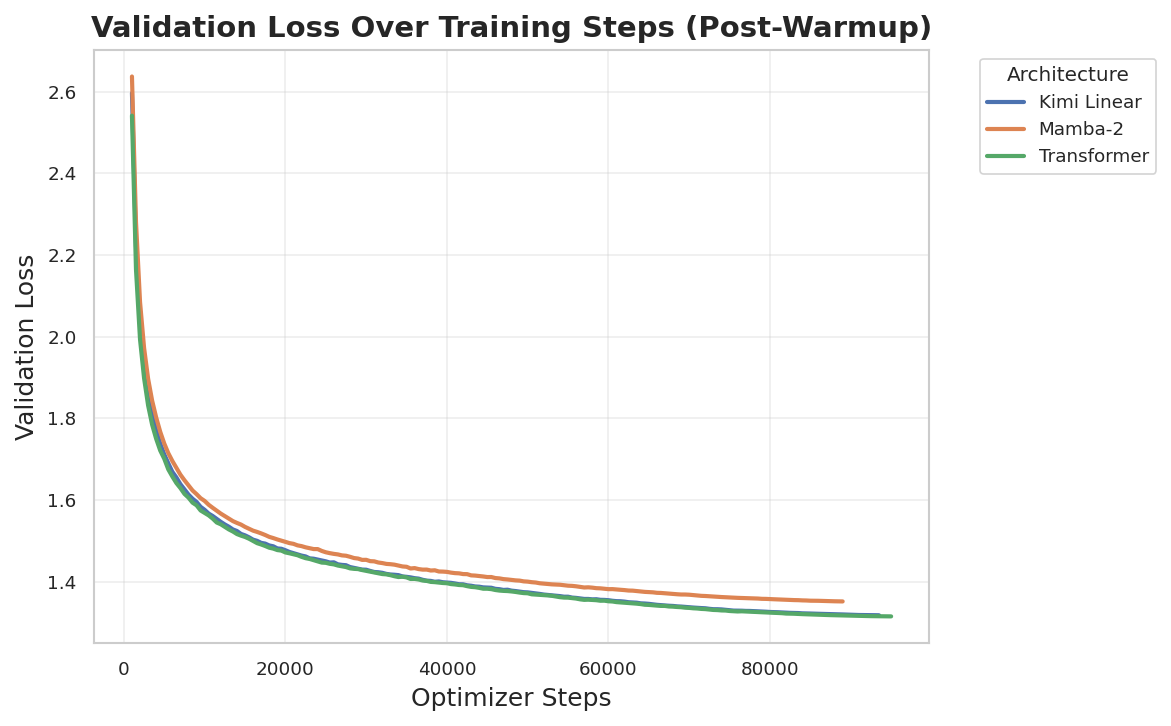

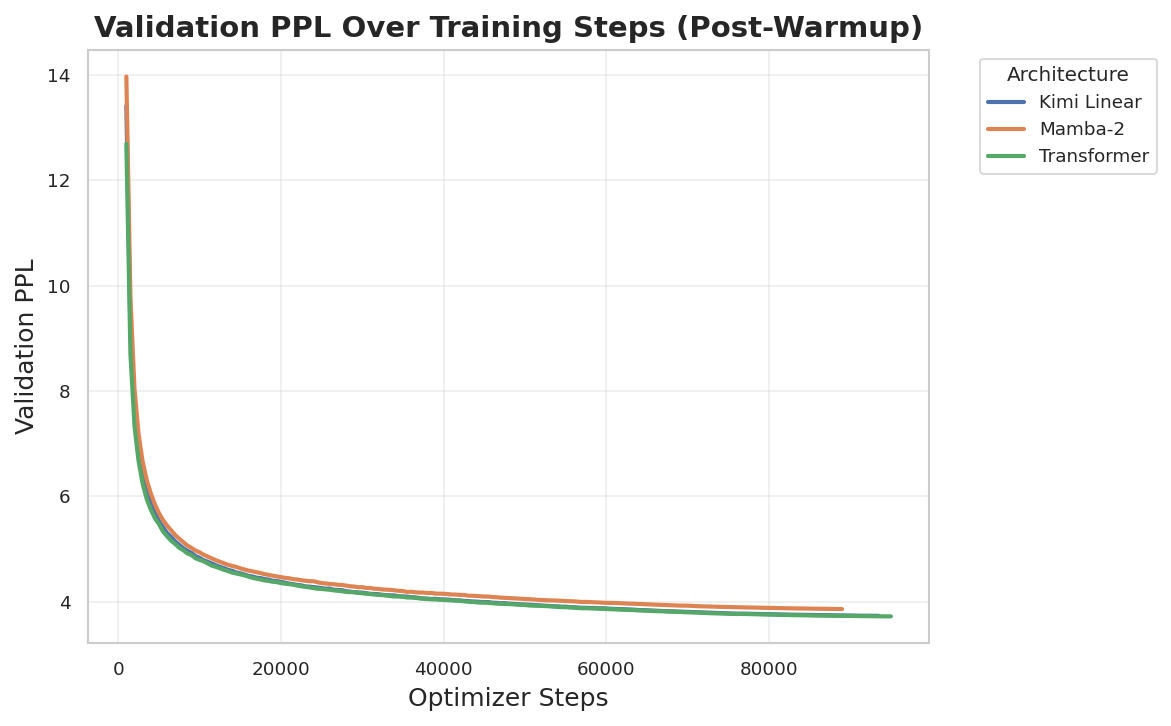

Generating plateau zoom plots...


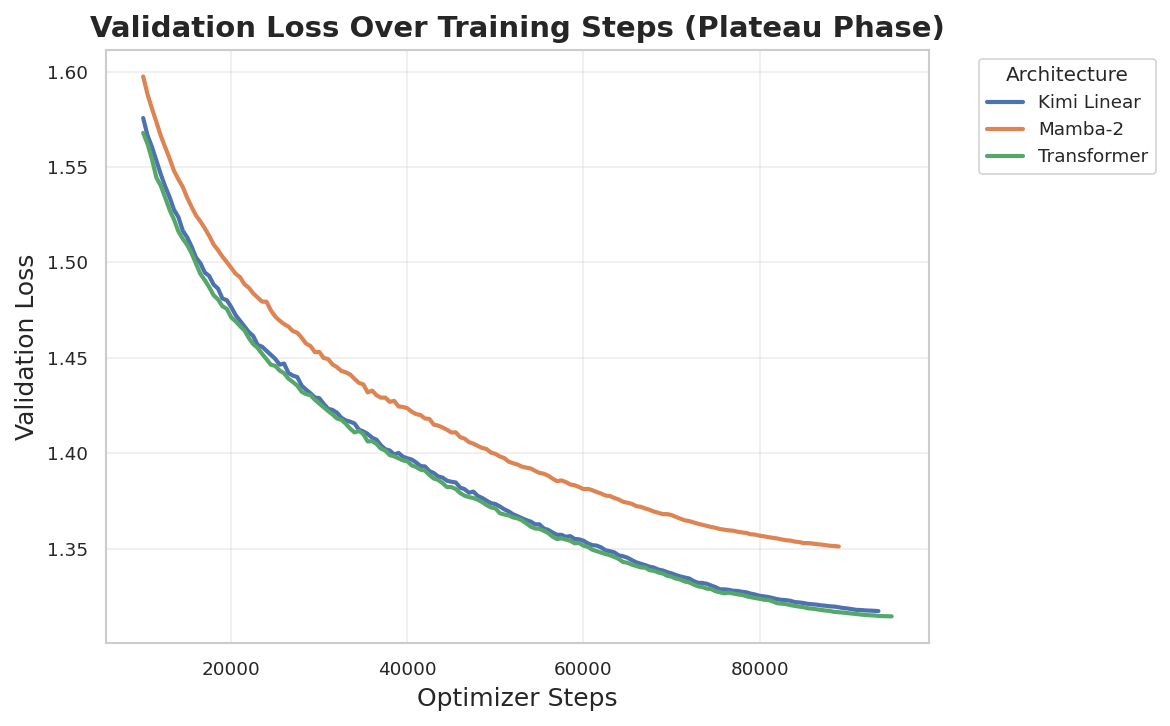

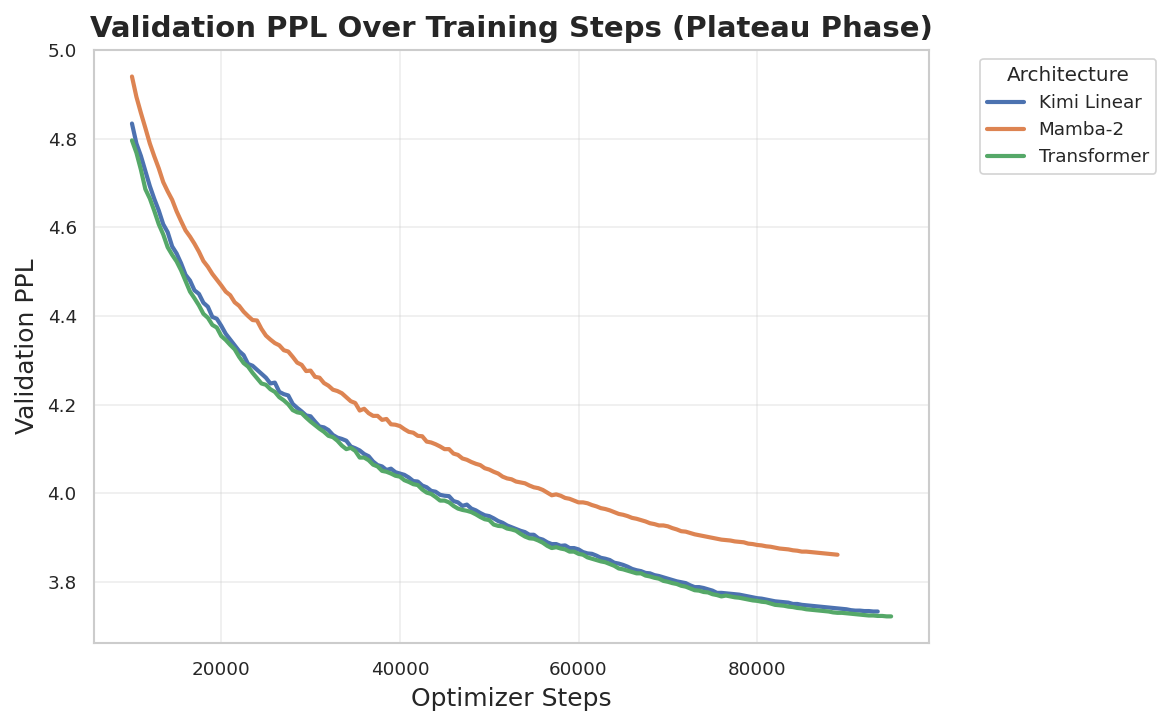

In [ ]:
log_files = {
    "Kimi Linear": "/content/drive/MyDrive/models/kimi_linear_toy/logs/toy_kimi_linear_half_tinystories_20260501_124445.jsonl",
    "Mamba-2": "/content/drive/MyDrive/models/mamba2_toy/logs/toy_mamba2_half_tinystories_20260501_090228.jsonl",
    "Transformer": "/content/drive/MyDrive/models/transformer_toy2/logs/toy_rope_transformer_half_param_matched_tinystories_20260503_085746.jsonl",
}


df_val = load_validation_logs(log_files, warmup_steps=1000)

# full Post-Warmup Curves (steps 1,000 to End)
print("Generating full post-warmup plots...")
plot_metric(df_val, metric='Validation Loss', title_suffix='(Post-Warmup)', start_step=1000)
plot_metric(df_val, metric='Validation PPL', title_suffix='(Post-Warmup)', start_step=1000)

#  Plateau / Convergence Phase (steps 10,000 to end)
print("Generating plateau zoom plots...")
plot_metric(df_val, metric='Validation Loss', title_suffix='(Plateau Phase)', start_step=10000)
plot_metric(df_val, metric='Validation PPL', title_suffix='(Plateau Phase)', start_step=10000)

In [ ]:
# Set paper-ready plot aesthetics
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300
})

def load_full_telemetry(log_files_dict):
    train_data = []
    val_data = []

    for model_name, file_path in log_files_dict.items():
        try:
            with open(file_path, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    step = record.get('optimizer_step', record.get('step'))

                    if step is None:
                        continue

                    if record.get('type') == 'step':
                        train_data.append({
                            'Model': model_name,
                            'Step': step,
                            'Train Loss': record.get('train_loss'),
                            'Grad Norm': record.get('grad_norm'),
                            'Tokens/Sec': record.get('tokens_per_sec'),
                            'TFLOPS': record.get('estimated_tflops')
                        })
                    elif record.get('type') == 'eval' and 'val_loss' in record:
                        val_data.append({
                            'Model': model_name,
                            'Step': step,
                            'Val Loss': record.get('val_loss')
                        })
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found. Skipping.")

    df_train = pd.DataFrame(train_data)
    df_val = pd.DataFrame(val_data)
    return df_train, df_val

def plot_gradient_stability(df_train, window=50):
    # rolling average of the gradient norm.

    # Calculate rolling mean to smooth out the extreme step-to-step noise
    df_train['Smoothed Grad Norm'] = df_train.groupby('Model')['Grad Norm'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(data=df_train, x='Step', y='Smoothed Grad Norm', hue='Model', linewidth=1.5, alpha=0.8, ax=ax)

    ax.set_title(f'Optimization Stability: Gradient Norms (Rolling Window={window})', fontweight='bold')
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Gradient Norm (L2)')
    plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_hardware_efficiency(df_train, drop_first_n_steps=2000):
   #bar chart of the average token throughput
   #initial steps are dropped to ignore initialization overhead

    # Filter out warmup/initialization
    stable_df = df_train[df_train['Step'] >= drop_first_n_steps]

    # Calculate means
    avg_throughput = stable_df.groupby('Model')['Tokens/Sec'].mean().reset_index()
    avg_throughput = avg_throughput.sort_values(by='Tokens/Sec', ascending=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = sns.barplot(data=avg_throughput, x='Model', y='Tokens/Sec', hue='Model', palette='viridis', legend=False, ax=ax)

    ax.set_title('Hardware Efficiency: Average Tokens Processed per Second', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Tokens / Second')

    # Add data labels on top of bars
    for p in bars.patches:
        bars.annotate(format(p.get_height(), '.0f'),
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha = 'center', va = 'center',
                      xytext = (0, 9),
                      textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_generalization_gap(df_train, df_val, model_name):
    #Attempt to look into possible overfit

    # Filter by model
    model_train = df_train[df_train['Model'] == model_name].copy()
    model_val = df_val[df_val['Model'] == model_name].copy()

    # Smooth training loss to match eval cadence visually
    model_train['Smoothed Train Loss'] = model_train['Train Loss'].rolling(50, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.lineplot(data=model_train, x='Step', y='Smoothed Train Loss', label='Train Loss', color='gray', alpha=0.6, ax=ax)
    sns.lineplot(data=model_val, x='Step', y='Val Loss', label='Validation Loss', color='blue', linewidth=2, ax=ax)

    ax.set_title(f'Generalization Gap: {model_name}', fontweight='bold')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    # Set y-limit to zoom in on the post-warmup area
    ax.set_ylim(bottom=1.0, top=2.5)

    plt.legend()
    plt.tight_layout()
    plt.show()

Plotting Gradient Stability...


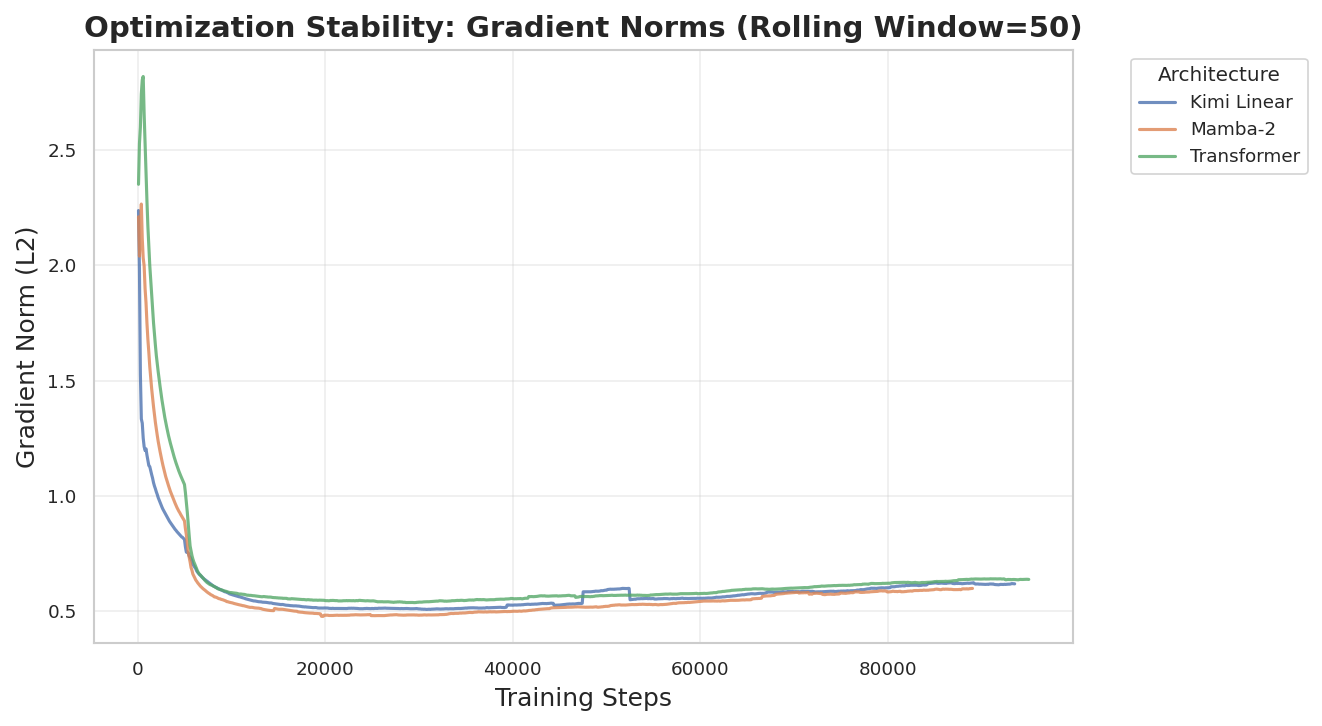


Plotting Hardware Efficiency...


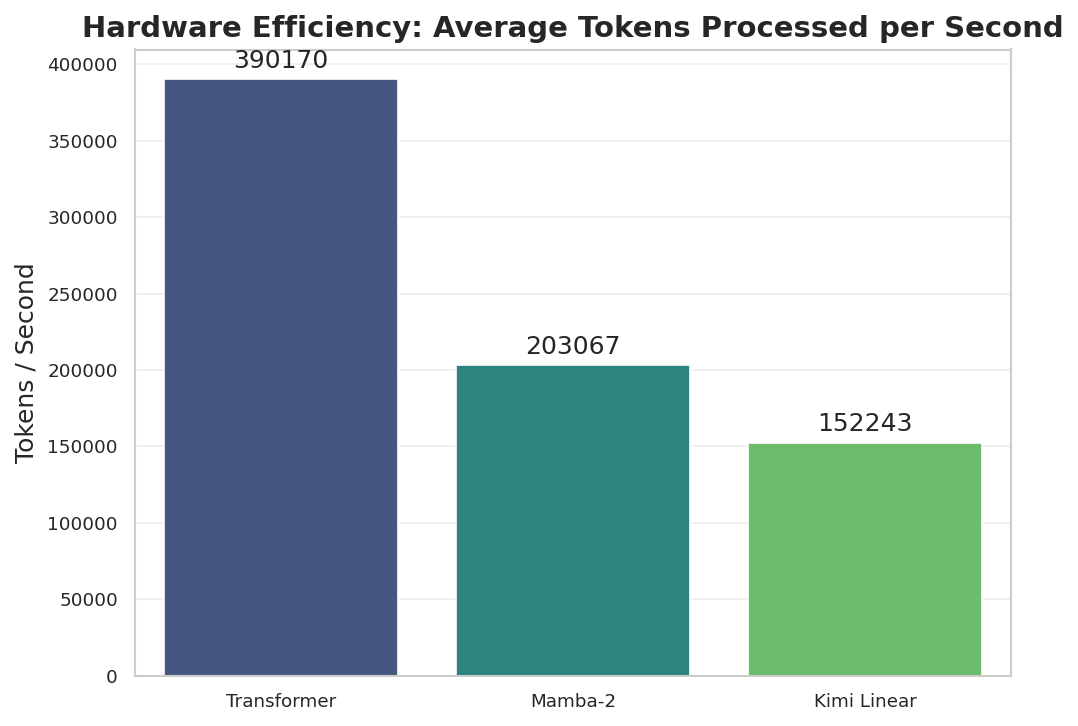


Plotting Generalization Gaps...


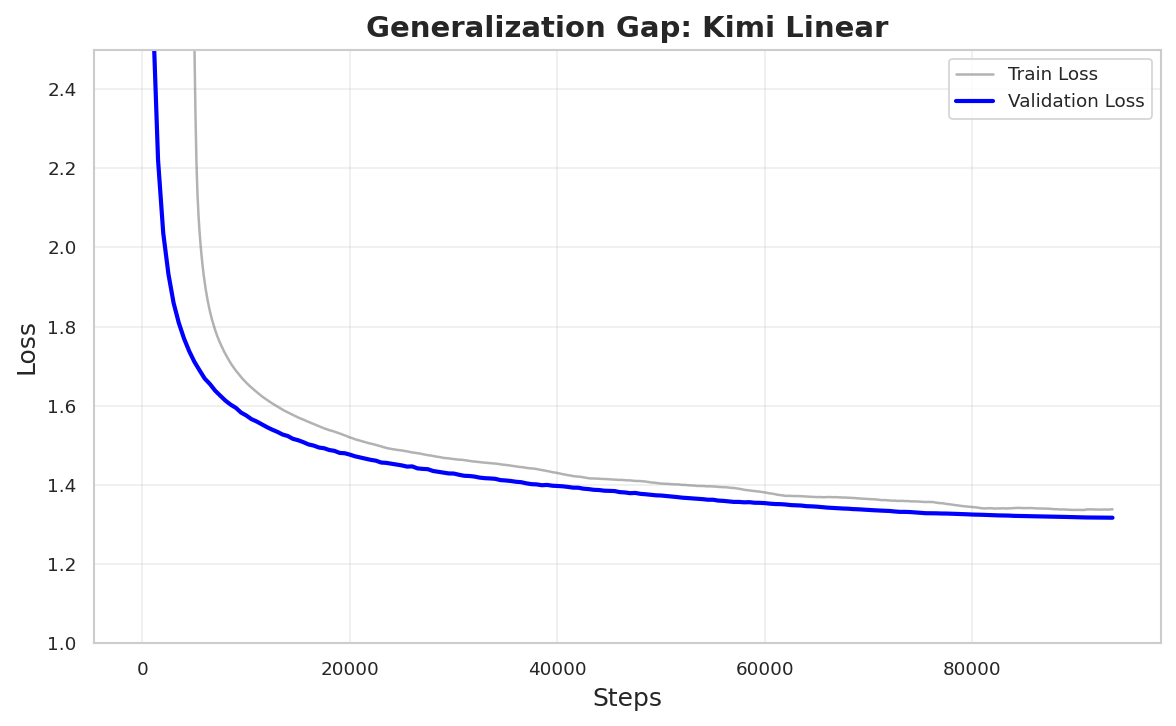

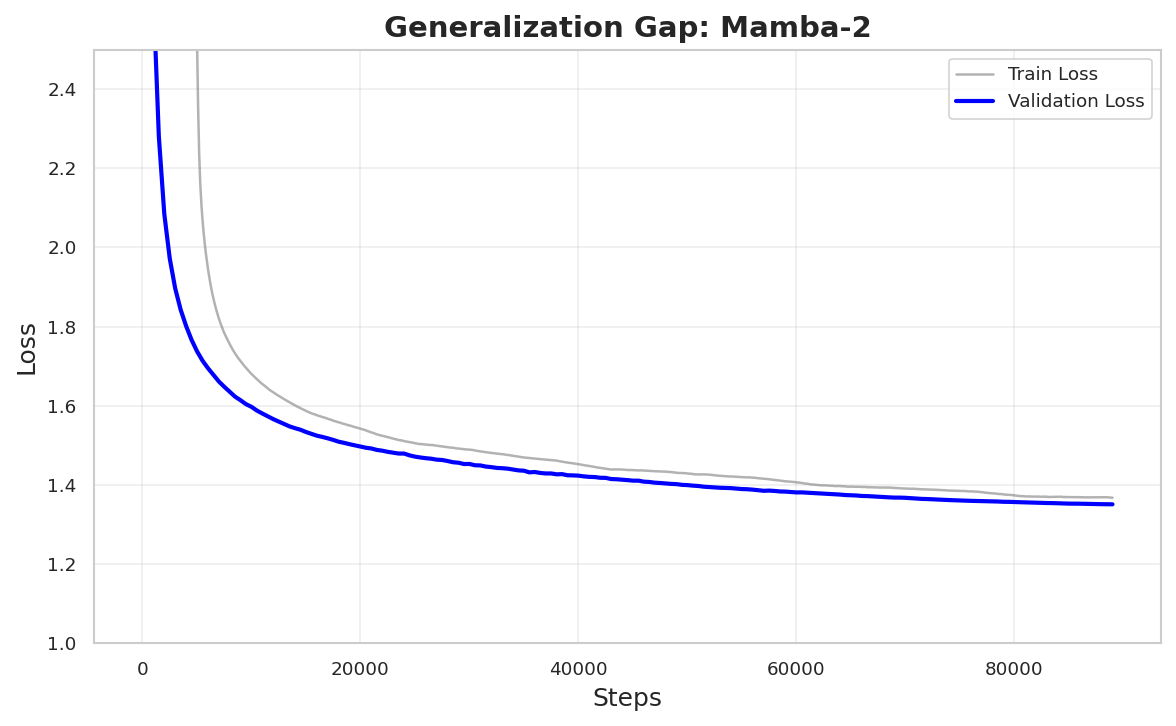

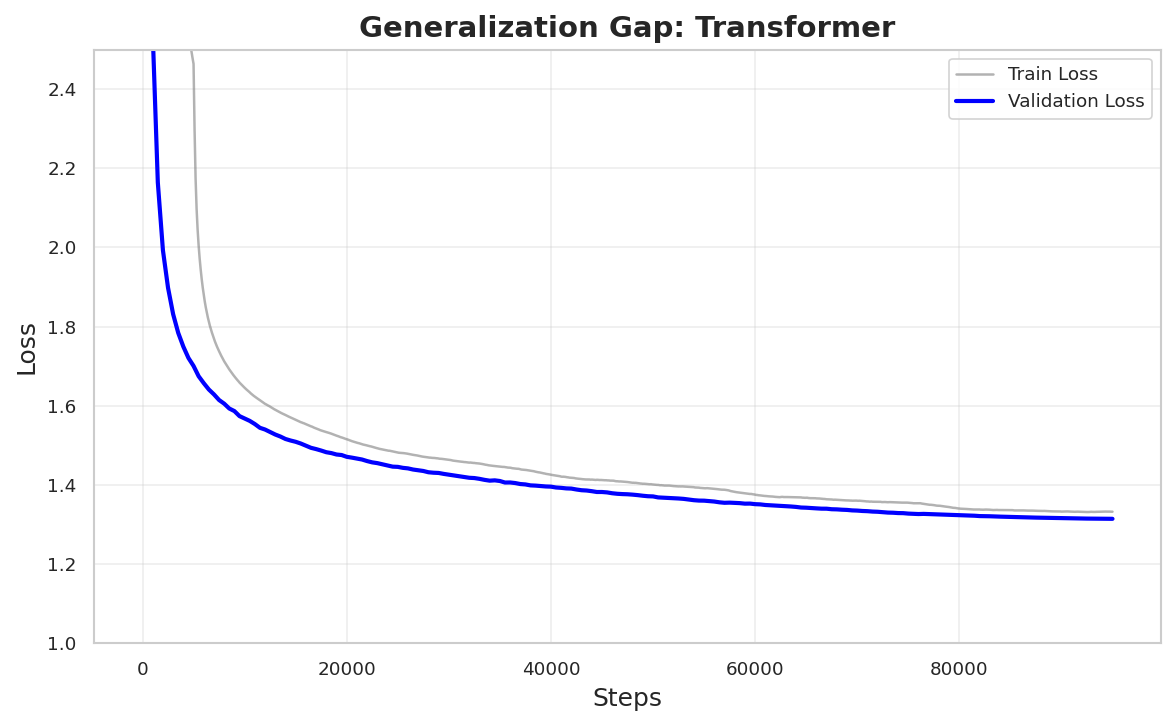

In [ ]:
df_train, df_val = load_full_telemetry(log_files)

print("Plotting Gradient Stability...")
plot_gradient_stability(df_train)

print("\nPlotting Hardware Efficiency...")
plot_hardware_efficiency(df_train)

print("\nPlotting Generalization Gaps...")
for model in log_files.keys():
    plot_generalization_gap(df_train, df_val, model)